## Define our use case

In this section, we will clearly define the problem we are trying to solve, the goals we want to achieve, and the reasons why fine-tuning is necessary. We will specify the target language, the task, the intended users, and the potential benefits of this project. This section sets the foundation for the rest of the notebook.


**Use Case: Adapting Gemma 2 for Arabic Language Storytelling**

**Problem:** Many languages lack robust digital resources. There's a need for AI tools that can enriching language revitalization and cultural preservation by enabling the creation and sharing of culturally relevant content.

**Goal:** We want to fine-tune Gemma 2 to generate compelling and culturally appropriate stories in Arabic, an eligible language with a rich oral tradition.

**Why Fine-tuning is Necessary:** While large language models like Gemma 2 possess broad linguistic knowledge, they likely haven't been trained extensively on specific  languages' nuances, cultural context, and storytelling traditions. Fine-tuning with relevant data will imbue the model with the necessary understanding to generate authentic and culturally sensitive stories. Out-of-the-box models may produce grammatically correct but culturally inappropriate or bland text.

**Detailed Breakdown:**

* **Target Language:** **Arabic** (العربية) a language eligible for the competition with a rich oral storytelling tradition..
* **Task:** Generate short stories, potentially incorporating elements of traditional Arabic folklore, values, and cultural practices.
* **Intended Users:** Arabic speakers, educators, and community members who wish to create and share stories in their native language.
* **Integration:** The generated stories could be used in educational materials, shared through community platforms, or even used as inspiration for artistic projects.

**Benefits of this Use Case:**

* **Language Revitalization:** Helps create engaging content in the target language, encouraging its use and transmission.
* **Cultural Preservation:** Allows for the retelling and adaptation of traditional stories, keeping cultural heritage alive.
* **Educational Resources:** Provides new and accessible storytelling resources for language learners.
* **Community Engagement:** Empowers community members to create and share their own stories, fostering a sense of ownership and creativity.

**In summary, we aim to fine-tune Gemma 2 to become a creative storytelling partner in the Arabic language, contributing to its revitalization and the preservation of its rich cultural heritage. This use case addresses a specific need within the broader goal of making language AI more inclusive and beneficial for diverse linguistic communities.**


# Inspiring Arabic Story Generation in Gemma2: Ideas to Ignite Creativity
<p style="text-align:center" align=center>
    <img src="https://raw.githubusercontent.com/abodacs/fine-tune-gemma2/refs/heads/main/images/preview.jpeg"  alt=" جملا ذو سنام على ظهره، يحمل بين أسنانه كتاب قديم. الكتاب مفتوح والصفحات مليئة برسومات جميلة للجمال والخيول والأشجار. الجمل ينظر مباشرة إلى الأطفال العرب الذين يجلسون حوله"
        width=1200 hight=1000
        >
</p> 
</p>
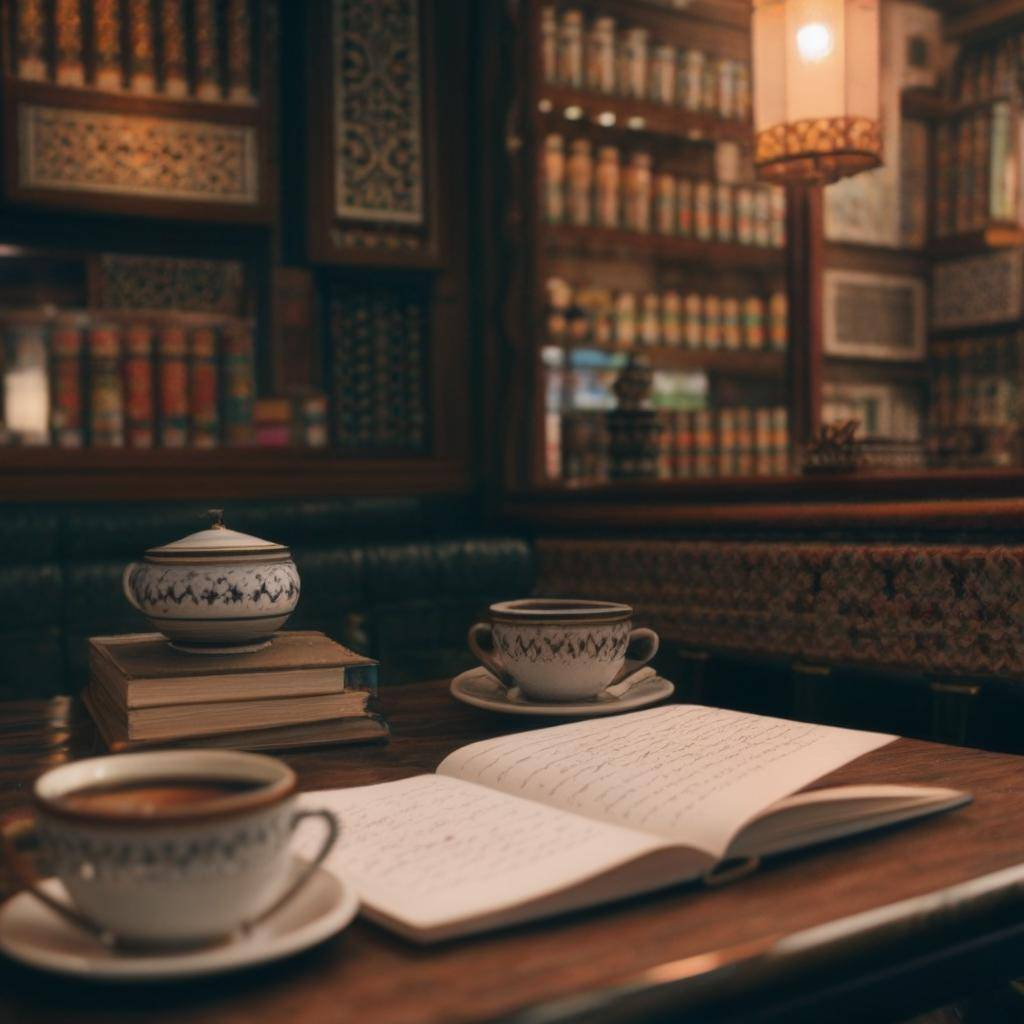

## The Genesis of Gemma2

**Gemma2** is the latest additions to the Gemma family of open language models for text and code. The authors of Gemma2 Paper , Gemma Team and Google DeepMind explained their effort as follows:

*“ We train Gemma 2 27B on 13 trillion tokens of primarily-English data, the 9B model on 8 trillion tokens, and the 2B on 2 trillion tokens. These tokens come from a variety of data sources, including web documents, code, and science articles. Our models are not multimodal and are not trained specifically for state-of-the-art multilingual capabilities. The final data mixture was determined through ablations similar to the approach in Gemini 1.0 (Gemini Team, 2023).”*

- **Pretrained** — This version of the model wasn’t trained on any specific tasks or instructions beyond the Gemma core data training set. We don’t recommend using this model without performing some tuning.
- **Instruction-tuned** — This version of the model was trained with human language interactions so that it can participate in a conversation, similar to a basic chat bot.
- **Mix fine-tuned** — This version of the model is fine-tuned on a mixture of academic datasets and accepts natural language prompts
  


Lower parameter sizes means lower resource requirements and more deployment flexibility.

 <p style="text-align:center">
    <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*EAeya6P09YymWRxbY8mrYw.png" alt="Gemma model sizes and capabilitie">
</p>
<p style="text-align:center">
    <em>Table 1.Gemma model sizes and capabilities, Source: GCP</em>
</p>
 

<p style="text-align:center">
    <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*SnOsKtjtl-hlZtp2Xv84Yw.png" alt="core parameters of Gemma 2">
</p>
<p style="text-align:center">
    <em>Table 2. core parameters of Gemma 2, <a href="https://developers.googleblog.com/en/gemma-explained-new-in-gemma-2/">GCP</a>
</em>
</p>



### Before You begin

> Kaggle Notebook Setup
The notebook requires GPU to run. Access to the settings > Accelerators and choose GPU P100. A GPU has been selected. You are now ready to train!

#### Gemma setup


To get access to Gemma 2, follow these steps:

<ol>
  <li>Sign in or register on <a href="https://www.kaggle.com/">Kaggle</a></li>    
  <li>Visit the <a href="https://www.kaggle.com/models/google/gemma/transformer">Gemma 2 Model Card</a></li>
  <li>Accept the terms and conditions to gain access to the model</li>
  <li>Once approved, you can use the model in your Kaggle notebooks or download locally</li>
</ol>

## 1. Dataset Creation/Curation (Focusing on Modern Standard Arabic)

This section details the process of creating and curating the dataset used to fine-tune Gemma 2. We'll explore the data sources, the preprocessing steps, the quality assurance measures, and the final structure of the dataset. We will focus specifically on the Modern Standard Arabic (MSA) portion of the AraStories dataset.


The [AraStories](https://github.com/UBC-NLP/arastories) dataset [MIT] includes data for various Arabic dialects. For this explanation, we will focus specifically on the Modern Standard Arabic (MSA) portion, which is designed to serve as a benchmark for Arabic story generation in this formal variety of the language. The MSA portion of the dataset is contained within a single CSV file. This file includes two columns: "Story" and "Prompt" and 996 MSA samples.

### 1.1. Data Sources (MSA)

The MSA stories in the dataset were collected from a variety of sources suitable for this formal language, including:

*   **Literary Works:** Stories sourced from well-known Arabic literature in MSA, encompassing both classical and contemporary works.
*   **Online Platforms:** Stories found on online platforms, blogs, and forums where Arabic stories in MSA are shared.
*   **Creative Contributions:** Original stories created by native speakers specifically for this dataset in MSA, ensuring a diverse range of formal narratives.

The MSA prompts were designed to align with these stories, providing context or initial sentences that could be used to generate the corresponding MSA stories. These prompts were crafted to cover a wide range of scenarios, themes, and styles appropriate for MSA, challenging models in generating coherent and contextually appropriate stories in this formal register.

### 1.2. Preprocessing Steps (MSA)

The MSA portion of the dataset underwent several preprocessing steps to ensure consistency and quality:

#### 1.2.1 Text Cleaning
Text cleaning involved the removal of irrelevant characters using regular expressions with Python's `re` module. This included removing emoticons, non-Arabic characters.

#### 1.2.2 Normalization
Normalization standardized the Arabic text through techniques such as diacritics removal using the PyArabic library. Further normalization addressed varying writing styles by standardizing Hamza and Alef usage and correcting common orthographic variations using a rule-based system.


### 1.2.3 Quality Assurance (MSA)

To ensure the quality and consistency of the MSA data, a rigorous evaluation process was implemented utilizing the advanced capabilities of GPT-4. Instead of manual review, we leveraged GPT-4's proficiency in natural language understanding and generation to assess the quality of our dataset. Specifically, GPT-4 evaluated each story and its corresponding prompt based on predefined criteria for coherence, relevance, grammatical accuracy, and stylistic consistency within the MSA register.

For each sample in the MSA dataset, GPT-4 received a structured input containing both the prompt and the story. The evaluation prompts provided to GPT-4 were designed to elicit specific feedback on key aspects of data quality. Here are examples of the evaluation prompt used:

> You are an expert in Arabic language, its dialects, and storytelling. I would like your help in evaluating a story written by a student based on a set of instructions. You are expected to give a score out of five based on the  following features:
>
>  **Fluency:** How smooth and natural the text is, including appropriate grammar, vocabulary, and sentence structure.
>  **Coherence:** The logical connection and flow of sentences and ideas, making the text easy to understand.
>  **Following Instructions:** How well the text adheres to the provided instructions or task requirements.
>  **Consistency:** How consistently accurate and uniform the information and style are throughout the text.
>  **Variety:** How well does the model generate story in the required Arabic variety?
>  Give the scores directly without explanations or additions. I will first give you the instructions on which the story was based, followed by the story written by the student.
> Remember, I want the evaluation directly without explanation. {prompt_content}



### 1.3 Considerations for Data Quality and Cultural Sensitivity (MSA)


**Cultural Relevance:**  Careful consideration was given to selecting **MSA** stories and prompts to ensure they reflected a diverse array of cultural contexts relevant to the formal use of the language. For instance, themes of resilience in the face of adversity, frequently encountered in classic Arabic literature, were prioritized. Furthermore, stories promoting ethical behavior firmly rooted in Islamic tradition were included, alongside narratives reflecting historical events from an **MSA** perspective. The overarching aim was to guarantee the content resonated with a broad audience familiar with formal Arabic and its cultural underpinnings, deliberately avoiding overly specific or colloquial themes more appropriate for dialectal content.

**Linguistic Accuracy:** Maintaining high **linguistic accuracy** was paramount. This critical objective was achieved through a stringent **manual quality assurance process**, during which linguistic experts meticulously corrected any deviations from standard **MSA** grammar and vocabulary. Furthermore, if applicable, a carefully engineered prompting strategy played a crucial role in guiding any generative models towards producing linguistically accurate **MSA** output. While automated grammar checking tools are a possibility, they were not explicitly mentioned.

**Sensitivity:** A dedicated cultural sensitivity review was conducted by experts possessing in-depth knowledge of Arab cultural norms and values. Strict criteria were applied to meticulously filter out any content potentially perpetuating negative stereotypes about Arab cultural groups or other communities." Similarly, for "disrespecting **religious beliefs or practices**," specify "Islamic or other religious beliefs or practices." For "avoided **politically sensitive topics**," clarify what constitutes 'politically sensitive' in this context (e.g., "avoided politically sensitive topics that could be divisive or misrepresentative").

The implementation of this GPT-4 based quality evaluation process allowed for an automated way to detect inconsistencies or errors. This rigorous process was crucial to maintaining the integrity of the dataset.

### 1.4 Dataset Structure (MSA)

*   **MSA Dataset:** Contains stories and prompts specifically in Modern Standard Arabic, designed for tasks involving formal and literary Arabic story generation. Each entry in the MSA dataset consists of two fields: 'prompt' (text) and 'story' (text).".

This MSA dataset, comprising [996] samples, is specifically designed to be used independently for research focused on generating stories in this specific Arabic variety.

### Conclusion (Focusing on MSA)

The MSA portion (996 samples) of the AraStories dataset provides a valuable resource for researchers and developers working on Arabic story generation specifically in Modern Standard Arabic. Its careful curation ensures that it is a useful tool for training and evaluating large language models on the task of generating coherent, contextually appropriate, and culturally relevant stories in this formal variety of Arabic.


# 2. Setup development environment

This section covers the essential steps for setting up the development environment. We will install the necessary libraries, load the pre-trained Gemma 2 model, configure the tokenizer, and prepare the environment for fine-tuning. We will also discuss the rationale behind each step.

In [ ]:
import warnings
import logging


logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

First step is to install Hugging Face Libraries and Pyroch, including trl, transformers and datasets. If you haven't heard of trl yet, don't worry. It is a new library on top of transformers and datasets, which makes it easier to fine-tune

In [ ]:
# Install essential libraries for NLP and efficient fine-tuning
!pip install -qqq -U transformers trl peft datasets huggingface_hub bitsandbytes accelerate sentence-transformers
# Install Kaggle-specific utilities for dataset and model management
!pip install -qqq --upgrade kagglehub[pandas-datasets,hf-datasets]
# Install `liger-kernel` Efficient Triton Kernels for LLM Training
!pip install liger-kernel

**Explanation of Libraries:**

*   **transformers:** This library, provided by Hugging Face, is a cornerstone for working with pre-trained Natural Language Processing (NLP) models like Gemma 2. It offers tools for various tasks including:
    *   **Model Loading:**  Easily loading pre-trained Gemma 2 models.
    *   **Tokenization:** Converting text into numerical representations that the model can understand.
    *   **Training & Fine-tuning:** Providing building blocks for training and adapting models to specific tasks.
    *   **Inference:** Generating text or performing other NLP tasks with the loaded or fine-tuned model.

*   **trl (Transformers Reinforcement Learning):** While the notebook primarily utilizes the `SFTTrainer` for supervised fine-tuning, `trl` is a broader library focused on Reinforcement Learning with Transformers. The `SFTTrainer` specifically simplifies the process of fine-tuning a language model on a dataset of text examples. In this context, it makes the task of fine-tuning Gemma 2 for story generation much easier by handling the training loop.

*   **peft (Parameter-Efficient Fine-Tuning):**  This library is critical for the memory-efficient fine-tuning approach used in the notebook (LoRA and QLoRA). It allows you to adapt large language models like Gemma 2 to specific tasks using significantly fewer resources. `peft` adds a small number of trainable parameters to the original model, leaving the majority of the model's weights frozen. This makes fine-tuning faster and requires less GPU memory.

*   **datasets:**  Another essential library from Hugging Face, `datasets` simplifies the process of loading and managing datasets for NLP tasks. In this notebook, it's used to load and process the Arabic story dataset ("abdullahabdelrhim/msa-prompts-stories") for fine-tuning Gemma 2. It provides efficient ways to access, filter, and prepare data.

*   **huggingface_hub:** This library provides a programmatic interface to the Hugging Face Model Hub. It's used for:
    *   **Downloading Models:**  Retrieving pre-trained models like Gemma 2.
    *   **Uploading Models:**  Potentially uploading the fine-tuned Gemma 2 model back to the Hub, as seen later in the notebook.

*   **bitsandbytes:** This library is crucial for enabling quantization techniques like QLoRA (Quantization-aware Low-Rank Adapters). By allowing the use of 4-bit or 8-bit data types, `bitsandbytes` significantly reduces the memory footprint of large language models during fine-tuning, making it possible to fine-tune them on GPUs with limited memory.

*   **Liger-Kernel:** This library is a set of Triton kernels designed specifically for LLM training. It can increase GPU training throughput by up to 20% and reduces memory usage by up to 60%.

*   **kagglehub[pandas-datasets,hf-datasets]:** This library provides specific utilities for interacting with Kaggle within a notebook environment. It enhances the basic `kaggle` CLI by providing:

### Importing libraries

In [ ]:
import os
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, TrainingArguments,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from datasets import load_dataset
from trl import SFTTrainer, setup_chat_format, SFTConfig

## 3. Loading and Preparing the Dataset

In this section, we will delve into the fine-tuning process, focusing on the use of the `trl` library and the `SFTTrainer`. We will explore Parameter-Efficient Fine-Tuning (PEFT) techniques like LoRA and QLoRA, explain the choice of hyperparameters, and show the training loop. This section will provide an understanding of how the model learns and adapts to the task of Arabic storytelling.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
dataset_name = "abdullahabdelrhim/msa-prompts-stories" # The instruction dataset to use

In [ ]:
# Adjust precision and attention based on GPU
if torch.cuda.get_device_capability()[0] >= 8:
    # Use bfloat16 and FlashAttention-v2 for newer GPUs (Compute Capability >= 8
    torch_dtype = torch.bfloat16
    attn_implementation = "flash_attention_2"
    !pip install -qqq flash-attn   # Install FlashAttention-v2 library
else:
    # Use float16 and eager attention for older GPUs
    torch_dtype = torch.float16
    attn_implementation = "eager"

**Configuration for Quantized Model Loading and Optimized Training: A Deep Dive**

This code block meticulously configures the loading of the pre-trained Gemma 2 model with 4-bit quantization and optimizes training via attention mechanism selection and gradient checkpointing.

*   **`BitsAndBytesConfig`**: This class configures the parameters for loading the model with 4-bit quantization using the `bitsandbytes` library.
    *   `load_in_4bit=True`: This boolean parameter activates the loading of the pre-trained model weights in 4-bit precision. This drastically reduces the GPU memory required to load and store the model, facilitating the fine-tuning of large models on resource-constrained hardware.
    *   `bnb_4bit_quant_type="nf4"`: This specifies the quantization data type to "nf4" (Normal Float 4). NF4 is a data type optimized for neural network weights, designed to minimize information loss during the quantization process compared to standard uniform integer quantization. It achieves this by distributing the quantization levels non-uniformly, concentrating them around zero where weight values are typically clustered.
    *   `bnb_4bit_compute_dtype=torch_dtype`: This parameter determines the data type used for computational operations within the 4-bit quantized layers. Setting it to `torch_dtype` (either `torch.bfloat16` or `torch.float16` based on GPU capability) ensures that computations are performed in the chosen precision, maintaining consistency and often maximizing performance within the constraints of the quantized weights.
    *   `bnb_4bit_use_double_quant=True`: Enabling double quantization further reduces memory overhead. It quantizes the quantization constants (the scaling and bias factors used to map the original weights to the 4-bit representation) themselves. This introduces a negligible additional computational cost but provides a further reduction in memory usage.

*   **`AutoModelForCausalLM.from_pretrained()`**: This method loads the pre-trained Gemma 2 model.
    *   `base_model`: This argument specifies the file path, `"/kaggle/input/gemma/transformers/2b-it/3"`, directing the function to the location of the pre-trained Gemma 2 model weights and configuration files within the Kaggle environment.
    *   `quantization_config=bnb_config`: This applies the previously defined 4-bit quantization scheme during the model loading process, leveraging the `bitsandbytes` library to load the weights in the specified 4-bit format.
    *   `device_map="auto"`: This argument automatically manages the distribution of the model's layers across the available GPU devices. PyTorch will intelligently place the layers to optimize memory usage and parallelism, simplifying multi-GPU setup if applicable.
    *   `attn_implementation=attn_implementation`: This sets the attention mechanism used by the model to the value determined in the previous conditional block (`"flash_attention_2"` or `"eager"`), optimizing performance based on the GPU's capabilities.

*   **`AutoTokenizer.from_pretrained()`**: This method loads the tokenizer associated with the pre-trained Gemma 2 model.
    *   `base_model`: Similar to the model loading, this argument, `base_model`, points to the directory containing the tokenizer configuration and vocabulary files for Gemma 2.
    *   `trust_remote_code=True`: This parameter allows the execution of custom code potentially included within the tokenizer configuration. While offering flexibility, it introduces potential security risks if the source of the pre-trained model is not trusted. In this case, since the model is from a known source (Google/Gemma), it is generally safe, and is sometimes necessary for certain custom tokenizers.

*   `model.config.use_cache = False`: This line disables the `use_cache` attribute in the model's configuration. When set to `True` (the default for inference), the model caches previously computed attention keys and values to speed up subsequent token generation. However, during training, especially with techniques like gradient checkpointing, this caching can interfere with gradient computations and increase memory consumption. Setting it to `False` ensures correct gradient calculation.

*   `model.gradient_checkpointing_enable()`: This method activates gradient checkpointing for the model. Gradient checkpointing is a memory optimization technique that reduces the memory footprint during training by strategically discarding intermediate activations in the forward pass and recomputing them on the fly during the backward pass. This trades computational time for memory savings, enabling the fine-tuning of larger models or the use of larger batch sizes on limited GPU memory.


In [ ]:
## config
from transformers import BitsAndBytesConfig, set_seed

# Set seed for reproducibility -- you don't need this unless you want full reproducibility
set_seed(42)

# BitsAndBytes configuration for memory-efficient model loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # Load model in 4-bit precision
    bnb_4bit_quant_type="nf4", # Use Normal Float 4 data type
    bnb_4bit_compute_dtype=torch_dtype, # Set compute data type based on GPU
    bnb_4bit_use_double_quant=True, # Enable double quantization for more memory saving
)

base_model = "/kaggle/input/gemma/transformers/2b-it/3"
# Load model with quantization and optimized attention
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation=attn_implementation
)
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
# Disable caching during training for gradient computation efficiency
model.config.use_cache = False
model.gradient_checkpointing_enable()

**Tokenizer Configuration for Fine-Tuning: A Parameter Specificity Analysis**

This code block focuses on the precise configuration of the tokenizer for subsequent fine-tuning operations.

*   **`tokenizer = AutoTokenizer.from_pretrained(base_model)`**:
    *   This line re-initializes the tokenizer using the pre-trained configuration located at the `base_model` directory. This explicit instantiation step ensures the tokenizer is correctly loaded and available, independent of any tokenizer potentially loaded during the model loading phase.

*   **`tokenizer.padding_side = 'right'`**:
    *   This attribute assignment sets the padding direction to 'right'. This configuration is a specific mitigation strategy for a potential numerical instability issue that can arise during mixed-precision training (specifically with float16). When padding is applied to the left side of sequences, it can, in certain scenarios, lead to buffer overflows in the GPU's memory when using the float16 data type, potentially causing training instability or errors. Right-sided padding circumvents this issue by ensuring padded values are appended to the right side of sequences.

*   **`tokenizer.pad_token = tokenizer.eos_token`**:
    *   This assigns the end-of-sequence token (`eos_token`) as the designated padding token. This is a standard practice in text generation tasks. By using the `eos_token` for padding, the model is consistently exposed to the sequence termination signal, even in padded regions. This helps prevent the model from interpreting padding tokens as meaningful content during training and generation.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model)
tokenizer.padding_side = 'right' # Fix weird overflow issue with fp16 training
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
dataset = kagglehub.load_dataset(
    KaggleDatasetAdapter.HUGGING_FACE,  # indicates that the dataset is structured in a manner compatible with Hugging Face Datasets
    dataset_name,
    "Formatted-MSA-prompts-stories-for-fine-tuning.csv",
)

def format_chat_template(row):
    """
     transforming individual data samples (rows) into a structured format suitable for instruction-based fine-tuning.
    """
    row_json = [
                {"role": "user", "content": row["Prompt"]},
                {"role": "assistant", "content": row["Story"]}]
    row["text"] = tokenizer.apply_chat_template(row_json, tokenize=False)
    return row

dataset = dataset.map(format_chat_template, num_proc=4)

split_dataset = dataset.train_test_split(train_size=0.9, test_size=0.1)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]
print(f"Size of the train set: {len(train_dataset)}. Size of the validation set: {len(eval_dataset)}")

In [ ]:
# show example
print(train_dataset["text"][2])

In [ ]:
token_lengths = [len(tokenizer(text['Story'])['input_ids']) for text in train_dataset]

In [ ]:
import matplotlib.pyplot as plt
plt.hist(token_lengths, bins=30, color='blue')
plt.title('Token Length Distribution')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()

### 4. Fine-tune LLM using `trl` and the `SFTTrainer`.


LoRA (Low-Rank Adaptation) stores changes in weights by constructing and adding a low-rank matrix to each model layer. This method opens only these layers for fine-tuning, without changing the original model weights or requiring lengthy training. The resulting weights are lightweight and can be produced multiple times, allowing for the fine-tuning of multiple tasks with an LLM loaded into RAM *without retraining the entire model*.

<p style="text-align:center">
    <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*K2BbII_ChKSuetrKOORZZw.jpeg" alt="Low-Rank Adaptation ">
</p>
<p style="text-align:center">
    <em>.An illustration of regular finetuning (left) and LoRA finetuning (right)<a href="https://magazine.sebastianraschka.com/p/lora-and-dora-from-scratch">LoRA</a>
</em>
</p>


<p style="text-align:center">
    <img src="https://raw.githubusercontent.com/abodacs/fine-tune-gemma2/refs/heads/main/images/-AI-Tinkerers-Ottawa-Fine-tuning-Whisper-with-PEFT-LORA-w-Rishab-Bahal-YouTube-01-09-2025_10_54_PM.png ">
</p>
<p style="text-align:center">
    <em>LLM trainable parameters increase with model size and rank, as shown in this table.
<a href="https://www.youtube.com/watch?v=G51AHmGGrys&t=510s">Fine tuning with PEFT LORA</a>
</em>
</p>


QLoRA (Quantized Low-Rank Adaptation) is an efficient fine-tuning approach that enables large language models to run on smaller GPUs by using 4-bit quantization. This method preserves the full performance of 16-bit fine-tuning while reducing memory usage, making it possible to fine-tune models with up to 65 billion parameters on a single 48GB GPU. QLoRA combines 4-bit NormalFloat data types, double quantization, and paged optimizers to manage memory efficiently. It allows fine-tuning of models with low-rank adapters, significantly enhancing accessibility for AI model development.


We use **Parameter-Efficient Fine-Tuning (PEFT)** techniques, specifically **LoRA** and **QLoRA**, to efficiently adapt Gemma 2 for Arabic story generation. Traditional fine-tuning of large models is computationally expensive, requires a lot of resources, and can cause 'catastrophic forgetting.' **LoRA** addresses this by adding small, trainable low-rank matrices to the model while freezing the original weights. **QLoRA** builds upon LoRA by quantizing the model's weights to 4 bits, reducing GPU memory needs further

 **QLoRA Specifics:** QLoRA uses several techniques to minimize memory usage: 4-bit NormalFloat (NF4) quantization, which reduces information loss compared to standard quantization; double quantization, which further reduces memory by quantizing the quantization constants; and paged optimizers, which manage optimizer states more efficiently. These techniques allow fine-tuning of large models on consumer-grade GPUs.


*   **Hyperparameter Tuning :**  While the provided notebook implements a specific configuration for LoRA, it's important to acknowledge that hyperparameter tuning is a crucial step for optimizing the performance of the fine-tuned model. In a more extensive setup (potentially outside the constraints of a quick Kaggle Notebook demonstration), we would explore a range of values for key LoRA hyperparameters, including:

    *   **Rank (r):** The rank of the low-rank matrices. A higher rank allows for more flexibility in adapting the model but also increases the number of trainable parameters. We might experiment with values like 8, 16, 32, 64, and 128 to find the optimal balance between performance and efficiency.
       -  We followed guidance from resources such as [Practical Tips for Finetuning LLMs Using LoRA (Low-Rank Adaptation)](https://magazine.sebastianraschka.com/p/practical-tips-for-finetuning-llms)
    *   **Lora Alpha (lora_alpha):** A scaling factor that adjusts the magnitude of the LoRA updates. It's often beneficial to set `lora_alpha` to be larger than `r` to improve training stability. We could try values ranging from `r` to `2*r` or even higher.
    *   **Lora Dropout (lora_dropout):** A dropout probability applied to the LoRA layers to prevent overfitting. We might explore values like 0.0, 0.1, and 0.2.
    *   **Learning Rate:**  The learning rate controls the step size during optimization. Finding an appropriate learning rate is critical for stable and effective training. We could experiment with learning rates ranging from 1e-5 to 1e-4, potentially using learning rate schedulers (like cosine annealing with restarts) for finer control.
    *   **Batch Size and Gradient Accumulation:**  These parameters influence the stability and efficiency of training. We might experiment with different batch sizes and adjust the `gradient_accumulation_steps` accordingly to fit within the GPU memory limits.
    *   **lr_scheduler_type**="cosine": The learning rate is adjusted according to a cosine schedule. It starts at the value specified in learning_rate and then gradually decreases.

    *  **warmup_steps**=2: For the first two epochs, the learning rate is adjusted by increasing its value instead of decreasing it. The aim is to stabilize the learning process.

    *  **Gradient_accumulation_steps**=3: To save memory. I accumulate the gradients over two steps before updating the model weights.

With these parameters, I've tried to find a training setup with low memory requirements, thanks to the use of gradient accumulation, gradient checkpointing, a small batch size, with the paged_adamw_32bit optimizer.

**Low-Rank Adapter (LoRA) Configuration for Parameter-Efficient Fine-Tuning: A Detailed Specification**

This code block defines the configuration for Low-Rank Adapters (LoRA), a parameter-efficient fine-tuning technique, for adaptation of the pre-trained Gemma 2 model.

*   **`peft_config = LoraConfig(...)`**:
    *   This instantiates a `LoraConfig` object, encapsulating the specific parameters for the LoRA adaptation.
    *   `r=64`: This parameter defines the rank of the low-rank matrices used in the LoRA adaptation. The rank dictates the dimensionality of these matrices. A higher rank (e.g., 64) allows the LoRA adapters to model more complex transformations, potentially capturing more intricate task-specific nuances. However, it also increases the number of trainable parameters within the adapters, introducing a trade-off between model flexibility and parameter efficiency.
    *   `lora_alpha=128`: This parameter represents the scaling factor applied to the updates from the LoRA adapters. The updates to the original model's weights are scaled by this factor. It is often recommended to set `lora_alpha` to a value between `r` and `2*r`. A higher `lora_alpha` amplifies the impact of the LoRA adapters' learned representations on the base model.
    *   `lora_dropout=0.1`: This parameter specifies the dropout probability applied to the LoRA adapter layers. Dropout is a regularization technique where, during training, a fraction (here, 10%) of the neurons are randomly deactivated. This helps prevent overfitting by reducing the co-adaptation of neurons and promoting more robust feature learning.
    *   `bias="none"`: This parameter dictates whether bias terms are included in the LoRA adapter layers. Setting it to `"none"` excludes bias terms. Including bias can offer additional flexibility but also increases the number of trainable parameters.
    *   `target_modules="all-linear"`: This parameter specifies the types of layers within the base model to which LoRA will be applied. Setting it to `"all-linear"` targets all linear layers (e.g., the query, key, value projection layers in attention, and the feedforward layers), enabling adaptation across a broad range of the model's parameters. Targeting specific modules offers finer-grained control but requires more task-specific knowledge.
    *   `task_type="CAUSAL_LM"`: This parameter explicitly declares the task for which the model is being fine-tuned as Causal Language Modeling. This informs the PEFT library about the nature of the task, which can influence how the adapters are integrated and trained.


In [ ]:
## Low-Rank Adapter (LoRA) Configuration for Parameter-Efficient Fine-Tuning
adaptor_model_name = "gemma-2b-stories-arabic-finetuned"  # Identifier for the LoRA adapter
output_dir = f"/kaggle/working/{adaptor_model_name}"  # Directory for saving the fine-tuned adapter 

# LoRA config based on QLoRA paper & Sebastian Raschka experiment
peft_config = LoraConfig(
        r=64,  # Rank of the low-rank matrix
        lora_alpha=128,  # Scaling factor for LoRA typically start with alpha=r and go upto alpha=2r
        lora_dropout=0.1, # Dropout probability for regularization
        bias="none", # Disables bias terms in LoRA layers
        target_modules="all-linear", # Applies LoRA to all linear layers
        task_type="CAUSAL_LM", # Specifies causal language modeling task
)

In [ ]:
# Integration of Low-Rank Adapters into the Base Model: Applying Parameter-Efficient Fine-Tuning
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

## **Configuration of Training Hyperparameters: A Detailed Exposition**

This code block meticulously configures the `SFTConfig` dataclass, which encapsulates all hyperparameters governing the model fine-tuning procedure.

*   **`output_dir=output_dir`**: Specifies the filesystem path, determined by the `output_dir` variable, where the fine-tuned model's weights, configuration files, and intermediate checkpoints are persistently stored. This also serves as the local repository identifier.

*   **`logging_dir="./logs"`**: Defines the directory, `"./logs"`, where training-related logs, including loss values and other relevant metrics, are written for monitoring and analysis.

*   **`num_train_epochs=5`**:  Determines the total number of training epochs, representing the count of complete iterations over the entire training dataset. Increasing this value allows the model to further refine its weights but also increases training time and the risk of overfitting.

*   **`per_device_train_batch_size=2`**: Sets the micro-batch size used for training on each individual GPU. Smaller batch sizes reduce GPU memory consumption but can lead to noisier gradient updates.

*   **`gradient_accumulation_steps=3`**:  Specifies the number of forward passes with subsequently accumulated gradients before a backward pass and weight update is performed. This technique emulates a larger effective batch size ( `per_device_train_batch_size` * `gradient_accumulation_steps`) when memory constraints limit the direct use of a larger batch.This allows the model to train with an effective batch size of 6, while only using a batch size of 2 in memory, which is particularly useful when training large models on hardware with limited memory.

*   **`gradient_checkpointing=True`**: Activates gradient checkpointing, a memory optimization technique that reduces GPU memory usage during training by trading off computational cost. Intermediate activations are not stored but recomputed during the backward pass. The argument `gradient_checkpointing_kwargs={'use_reentrant':False}` configures the specific implementation of gradient checkpointing. Setting `use_reentrant=False` can often offer better performance. Gradient checkpointing reduces the memory footprint by only storing some of the activations during forward propagation and recomputing the others during backward propagation. This is a useful technique when working with large models on GPUs with limited memory, allowing for larger models and batches to be used.

*   **`optim="paged_adamw_32bit"`**:  Selects the Paged AdamW optimizer. This variant of the AdamW optimizer, implemented in 32-bit precision, is memory-efficient due to its ability to handle optimizer states more effectively, especially when dealing with large models. The **Paged AdamW optimizer** is chosen for its memory efficiency, as it allows the optimizer states to be stored more efficiently, which helps in training large models that would otherwise not fit in memory. Compared to the commonly used AdamW optimizer, it uses a paged memory management strategy which allows it to store the optimizer states more efficiently, therefore reducing memory usage. This also allows to train large models or use larger batch sizes on the same hardware

*   **`weight_decay=0.01`**: Weight decay, also known as L2 regularization, is a technique commonly used in deep learning to prevent overfitting.This encourages the model to learn smaller weights, which can lead to better generalization performance.The weight decay to apply (if not zero) to all layers except all bias and LayerNorm weights.  

*   **`logging_steps=10`**: Defines the interval, in training steps, at which training metrics (e.g., loss) are logged. During training, the model's training loss and evaluation loss are logged every 10 training steps. This is useful for monitoring the training process and diagnosing potential issues. These logs allow us to monitor how the model is learning and identify any trends such as overfitting or underfitting.

*   **`save_strategy="epoch"`**:  Specifies the policy for saving model checkpoints. Setting it to `"epoch"` dictates that a checkpoint is saved at the completion of each training epoch. Alternative strategies include saving at fixed intervals of training steps.

*   **`bf16=False`** and **`tf32=False`**: These boolean flags disable the use of Brain Floating Point 16 (bfloat16) and TensorFloat-32 (TF32) mixed-precision training, respectively. Enabling these typically requires specific hardware (e.g., NVIDIA Ampere architecture or newer for TF32) and appropriate software configurations.

*   **`learning_rate=2e-4`**: Sets the initial learning rate for the optimizer. This hyperparameter critically controls the step size during the weight update phase of training. Smaller values lead to slower convergence but can improve stability; larger values can accelerate learning but risk overshooting the optimal parameters.

*   **`max_grad_norm=0.3`**:  Implements gradient clipping, where the gradients are scaled down if their L2 norm exceeds this threshold. This technique helps prevent exploding gradients, a common issue in training deep neural networks, particularly when using techniques like QLoRA.

*   **`warmup_steps=50`**: Specifies the number of initial training steps during which the learning rate is gradually increased from zero to the configured `learning_rate`. This "warm-up" phase can improve training stability, especially at the beginning of training.

*   **`lr_scheduler_type="cosine"`**:  Selects the cosine learning rate scheduler. This scheduler reduces the learning rate following a cosine function from the initial value to a minimum value, potentially aiding convergence to a better minimum in the loss landscape.

*   **`load_best_model_at_end = True`**:  When set to `True`, the training process will monitor the evaluation metric and load the model checkpoint that achieved the best performance on the evaluation set at the conclusion of training. This helps prevent the model from overfitting, by choosing the model with the lowest evaluation loss. This implies that the model with the lowest loss on the validation set is the one that is used for the final evaluation and inference.

*   **`push_to_hub=False`**: Prevents the automatic upload of the fine-tuned model to the Hugging Face Model Hub during the training process.

*    **`use_liger=True`**: Enable Liger Kernel Triton kernels designed specifically for LLM training. It can effectively increase multi-GPU training throughput by 20% and reduces memory usage by 60%.

*   **`report_to="none"`**: Suppresses the reporting of training metrics to any external tracking or logging services.For more in-depth analysis and tracking, it is highly recommend to use experiment tracking tools, such as Weights & Biases or Comet, which allow for better visibility into the model's performance throughout the training process.


In [ ]:
# Training arguments
training_arguments = SFTConfig(
    output_dir=output_dir,                  # directory to save and repository id
    logging_dir="./logs",                   # Directory for storing training logs
    # max_steps=100,                         # for debugging
    num_train_epochs=5,                     # number of training epochs
    per_device_train_batch_size=2,          # batch size per device during training
    gradient_accumulation_steps=3,          # number of steps before performing a backward/update pass
    gradient_checkpointing=True,            # use gradient checkpointing to save memory
    gradient_checkpointing_kwargs={"use_reentrant":False}, # Solve ==> RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn
    optim="paged_adamw_32bit",              # use paged fused adamw optimizer
    logging_steps=10,                       # log every 10 steps
    save_strategy="epoch",                  # save checkpoint every epoch
    bf16=False,                             # use bfloat16 precision
    tf32=False,                             # Disable TF32 mixed precision
    learning_rate=2e-4,                     # Optimizer learning rate 
    max_grad_norm=0.3,                      # Gradient norm clipping threshold
    warmup_steps=50,                        # Linear learning rate warmup steps
    weight_decay = 0.01,
    lr_scheduler_type="cosine",             # Cosine learning rate decay schedule
    push_to_hub=False,                      # Prevent automatic push to Hugging Face Hub
    use_liger=True,                         # Enable Efficient Triton Kernels for LLM Training
    # neftune_noise_alpha=0.01,              # NEFTune is a technique to boost the performance of chat models. (didn't work)
    report_to="none",                       # Suppress reporting to external services
)

**Instantiation of the Supervised Fine-Tuning Trainer: Parameter Specificity Analysis**

This code block initializes the `SFTTrainer` object, which orchestrates the supervised fine-tuning process.

*   **`trainer = SFTTrainer(...)`**:
    *   This line instantiates the `SFTTrainer` class from the `trl` library, configuring it with the necessary components for supervised fine-tuning.
    *   `model`: This parameter takes the pre-trained Gemma 2 model, which has been augmented with the LoRA adapters using the `get_peft_model` function, as the foundation for fine-tuning.
    *   `train_dataset`: This parameter is assigned the `train_dataset` object, which contains the portion of the prepared dataset designated for training the model.
    *   `eval_dataset`: This parameter is assigned the `eval_dataset` object, containing the held-out portion of the dataset used for periodic evaluation of the model's performance during training. This allows for monitoring generalization and detecting overfitting.
    *   `peft_config`: This parameter is supplied with the `peft_config` object, which encapsulates the configuration parameters for the Low-Rank Adapters (LoRA), specifying how these adapters are integrated and trained.
    *   `tokenizer`: This parameter is assigned the `tokenizer` object, responsible for the tokenization and detokenization of text data throughout the fine-tuning process.
    *   `args`: This parameter is provided with the `training_arguments` object, which contains all the hyperparameters and training configurations defined in the previous steps, such as learning rate, batch size, and logging frequency.


In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    tokenizer=tokenizer,
    args=training_arguments,
)

**Initiation of the Fine-Tuning Process: Execution Commencement**

This code block triggers the execution of the supervised fine-tuning procedure.

*   **`trainer.train()`**:
    *   This line invokes the `train()` method of the instantiated `SFTTrainer` object. This method call commences the iterative process of fine-tuning the language model's parameters (specifically the LoRA adapter weights) on the provided training dataset, while periodically evaluating performance on the evaluation dataset, according to the configurations specified in the `TrainingArguments`. The fine-tuned adapter weights and intermediate checkpoints will be saved to the `output_dir` as training progresses. During the training process, the SFTTrainer uses the configured hyperparameters to iteratively adjust the LoRA adapter weights based on the training data. Every logging_steps, metrics are recorded. Also, every epoch the training process is evaluated against the evaluation set and the model with the best loss metric is loaded at the end if the flag `load_best_model_at_end` is enabled. The training is stopped when the number of epoch specified is reached, or the training process runs out of resources.


In [ ]:
# start training, the model saved to output directory
trainer.train()

**Artifact Preservation: Saving and Merging Fine-Tuned Adapters: Ensuring Model Persistence**

This code block ensures the preservation of the fine-tuned LoRA adapters and associated tokenizer.

*   **`trainer.model.save_pretrained(output_dir)`**:
    *   This line serializes and saves the trained LoRA adapter weights and the adapter configuration to the specified `output_dir`. This ensures that the learned adaptations are persistently stored and can be reloaded later without requiring retraining.

*   **`tokenizer.save_pretrained(output_dir)`**:
    *   This line saves the tokenizer's configuration and vocabulary files to the `output_dir`. This is crucial as the tokenizer is an integral part of the model pipeline, and the same tokenizer used during training must be used for inference to ensure consistent tokenization and detokenization.

In [ ]:
# Save artifacts
trainer.model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

In [ ]:
def get_loss_logs(trainer, loss_type='loss'):
    logs = trainer.state.log_history
    loss = [(x["step"], x[loss_type]) for x in logs if loss_type in x.keys()]
    return [x[1] for x in sorted(loss, key=lambda x: x[0])]

train_loss = get_loss_logs(trainer, 'loss')

plt.plot(train_loss, label='Training Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Execute this cell only if you are having memory issues.
import torch
import gc

def clear_hardwares():
    gc.collect()
    if torch.cuda.is_available():
        torch.clear_autocast_cache()
        torch.cuda.ipc_collect()
        torch.cuda.empty_cache()
    gc.collect()

# Flush memory
del trainer, model
clear_hardwares()

#### Merge LoRA adapter in to the original model

When using QLoRA, we only train adapters and not the full model. This means when saving the model during training we only save the adapter weights and not the full model. If you want to save the full model, which makes it easier to use with Text Generation Inference you can merge the adapter weights into the model weights using the merge_and_unload method and then save the model with the save_pretrained method.

**Adapter Integration: Merging LoRA Weights into the Base Model: Facilitating Standalone Deployment**

This code block merges the trained LoRA adapter weights into the base language model, creating a self-contained fine-tuned model.

*   **`from peft import AutoPeftModelForCausalLM`**:
    *   This imports the `AutoPeftModelForCausalLM` class, a utility for loading PEFT models.

*   **`model = AutoPeftModelForCausalLM.from_pretrained(output_dir, torch_dtype=torch_dtype, low_cpu_mem_usage=True)`**:
    *   This line loads the PEFT model (comprising the base model and the adapter configuration) from the `output_dir`. The `torch_dtype` argument ensures the model is loaded with the appropriate numerical precision, and `low_cpu_mem_usage=True` minimizes CPU memory footprint during loading.

*   **`merged_model = model.merge_and_unload()`**:
    *   This line performs the merging operation. The `merge_and_unload()` method of the PEFT model takes the learned weights from the LoRA adapters and integrates them directly into the corresponding layers of the base model. After merging, the adapter weights are no longer needed and are unloaded from memory, resulting in a standard `transformers` model with the fine-tuned parameters.

*   **`merged_model.save_pretrained(output_dir, safe_serialization=True, max_shard_size="2GB")`**:
    *   This line saves the newly created merged model to the `output_dir`. `safe_serialization=True` uses a safer saving method. `max_shard_size="2GB"` shards the model weights into multiple files of maximum 2GB each, which can be helpful for managing large model files.

In [ ]:
from peft import AutoPeftModelForCausalLM

# Load PEFT model on CPU
model = AutoPeftModelForCausalLM.from_pretrained(
    output_dir,
    torch_dtype=torch_dtype,
    low_cpu_mem_usage=True,
)

# Merge LoRA and base model and save
merged_model = model.merge_and_unload()
merged_model.save_pretrained(output_dir, safe_serialization=True, max_shard_size="2GB")

In [ ]:
del merged_model
clear_hardwares()

## 5. Test Model and run Inference

This section focuses on evaluating the performance of our fine-tuned model. We will load the model, define an inference function, test the model with various prompts, and explore basic Retrieval-Augmented Generation (RAG) techniques. This section demonstrates how to use the fine-tuned model and its ability to generate stories.

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

# Authenticate to Kaggle
os.environ["KAGGLE_USERNAME"] = user_secrets.get_secret("kaggle_username")
os.environ["KAGGLE_KEY"] = user_secrets.get_secret("kaggle_key")

**Model Uploading:**
The fine-tuned model was uploaded to the Kaggle Models hub for several key reasons:

*   **Accessibility and Sharing:** Uploading to Kaggle Models makes the fine-tuned model readily available to other users. This aligns with the goals of the competition and the spirit of open-source collaboration, allowing others to build upon this work, experiment with it, and further explore Arabic language generation.
*   **Ease of Use:** The Kaggle Models hub provides a streamlined way to access and integrate pre-trained and fine-tuned models directly into Kaggle Notebooks and other workflows. This removes the need for manual downloads or complex integration procedures and makes the model more convenient to use.
*   **Version Control and Management:** The Kaggle Models hub provides version control. Each upload is a new version, making it easier to track improvements or changes and enabling users to choose specific versions as needed.
*   **Community Contribution:** By uploading to the Kaggle Models hub, we contribute to the growing collection of community-driven models, which can become a valuable resource for the broader Kaggle and AI community.
*    **Specific Model Choice:** The specific model uploaded was the Gemma-2B model fine-tuned for Arabic storytelling due to its balance between model size and performance, enabling it to be used more readily, compared to the larger variations.
*    **Framework Choice:** The model was uploaded as a `PyTorch` framework for easy integration with the PyTorch library and its ecosystem.
*   **Parameter Efficiency:** The model uses QLoRA for fine-tuning and was merged in the end, making it lighter, and easier to use for inference.

In [ ]:
import kagglehub
from kagglehub.config import get_kaggle_credentials

cre = get_kaggle_credentials()
username = cre.username

# For PyTorch framework & `2b` variation.
# Replace the framework with "jax", "other" based on which framework you are uploading to.
kagglehub.model_upload(f'{username}/gemma2-kaggle/pyTorch/gemma-2b-stories-arabic-finetuned', 
                       output_dir, version_notes='improved accuracy', ignore_patterns=["checkpoint-*/*",])

print(f"The fine-tuned model was successfully uploaded to <a href='https://www.kaggle.com/models/{username}/gemma2-kaggle/pyTorch/gemma-2b-stories-arabic-finetuned'>Kaggle Models</a>.")

In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, PeftConfig
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Check for CUDA availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load Model with PEFT adapter
peft_model_id = "/kaggle/working/gemma-2b-stories-arabic-finetuned/"
tokenizer = AutoTokenizer.from_pretrained(peft_model_id, use_fast=False)
model = AutoPeftModelForCausalLM.from_pretrained(peft_model_id, device_map="auto", torch_dtype=torch_dtype)
model.to(device)
# Sets the module in evaluation mode.
model.eval()
# apply the torch compile transformation
model.forward = torch.compile(model.forward, mode="reduce-overhead", fullgraph=True)

**Explanation of `torch.compile` and `torch.inference_mode`:**

*   **`torch.compile(model.forward, mode="reduce-overhead", fullgraph=True)`**:  for faster text generation times, more efficient, allowing it to process input and produce output more quickly. However, it might increase the time of the first call.
    *   This line uses PyTorch's `torch.compile` function to optimize the model's forward pass for faster inference.
    *   `torch.compile` transforms the model's forward method into a more efficient version by analyzing the graph of operations and applying various optimizations. This can significantly reduce inference time, particularly when using a compiled model for the first time.
    *   `mode="reduce-overhead"` is used to optimize for cases where the model is compiled for use multiple times, aiming for reduced execution overhead, and maximizing the efficiency of each call.
    * `fullgraph=True` instructs `torch.compile` to treat the entire forward pass as a single graph, allowing for more aggressive optimizations.
*   **`with torch.inference_mode():`**: reduces the memory footprint of the model as well as increases the generation speed because it disables gradient calculation, and other training-related computation during inference.
    *   This context manager is used during the story generation to ensure the model is in inference mode, which disables features like gradient calculations, which are not needed during the prediction phase and can speed things up.
       
*   **Detailed Explanation of `model.generate()` Parameters:**  The `model.generate()` function in the provided inference code is configured with several important parameters that govern the text generation process:

    *   `inputs`: This argument unpacks the tokenized prompt that we want the model to continue. Before being fed to the `generate` function, the raw text prompt is converted into numerical tokens using the model's tokenizer. These tokens represent the starting point for the story generation.

    *   `max_new_tokens=640`: Allows you to control the maximum length and this is the maximum numbers of tokens to generate, ignoring the number of tokens in the prompt.
    *   `num_beams=4`: Beam search keeps track of the top num_beams most likely sequences at each step, which generally leads to more coherent and higher-quality text compared to greedy decoding.
    *   `repetition_penalty=1.2`: This parameter is used to discourage the model from repeating tokens or sequences.
        - A value of 1.0 means no penalty.
        - A value greater than 1.0 (e.g., 1.2) reduces the probability of generating tokens that have already appeared in the sequence, thus penalizing repetition. Higher values impose a stronger penalty and good for relatively small size models.
    *   `num_logits_to_keep=1`: This parameter is an optimization for memory efficiency, especially during long sequence generation. By setting `num_logits_to_keep=1`, we instruct the model to only retain the logits (the raw, unnormalized probabilities) for the very last token generated at each step. Calculating and storing logits for all possible tokens in the vocabulary at each step can consume a significant amount of memory, particularly for models with large vocabularies and during the generation of long sequences. By keeping only the last token's logits, we significantly reduce the memory footprint during inference. This optimization doesn't change the generated output but improves efficiency.
 
    *    `use_cache=True`: is a directive that optimizes the model's ability to handle sequential token processing by preserving and leveraging the contextual information from the self-attention mechanism across the sequence. This leads to more efficient and contextually coherent outcomes in language modeling tasks.

*   **Decoding Strategies:** The process of converting the model's probability distribution over the next token into an actual token sequence is called **decoding**. Different decoding strategies have different trade-offs in terms of the quality, creativity, and computational cost of the generated text.

    *   **Greedy Decoding (`do_sample=False`):** As mentioned earlier, greedy decoding always selects the token with the highest probability at each step. It's the simplest and fastest decoding strategy. However, it can be prone to generating repetitive or predictable text because it doesn't explore alternative, potentially more insightful continuations. It's like always choosing the most obvious word that comes to mind.

    *   **Beam Search:**  Beam search is a more sophisticated decoding algorithm that tries to find a better sequence by keeping track of multiple possible continuations (beams). At each step, it expands the most promising beams by considering the top `k` most likely next tokens for each beam. This allows the model to explore several possibilities simultaneously and often leads to higher quality and more coherent text than greedy decoding. However, beam search is computationally more expensive than greedy decoding as it needs to maintain and process multiple candidate sequences.

    *   **Sampling Methods (`do_sample=True`):**  Sampling methods introduce randomness into the decoding process. Instead of always picking the highest probability token, the model samples from the probability distribution over the next tokens. This can lead to more creative and diverse outputs.

        *   **Temperature Sampling:** As explained with the `temperature` parameter, this method adjusts the probability distribution to control randomness.
        *   **Top-k Sampling:** This method limits the sampling pool to the `k` most likely tokens, preventing the model from picking very low-probability (and potentially nonsensical) tokens.
        *   **Nucleus Sampling (Top-p Sampling):** This dynamically adjusts the sampling pool based on cumulative probability, allowing for more flexible and context-aware token selection.
    * [Source] [How to generate text: using different decoding methods for language generation with Transformers](https://huggingface.co/blog/how-to-generate)


In [ ]:
def generate_story(prompt_example: str, add_arabic_prefix: bool =False, generation_params: dict = None) -> str:
    """Generates an Arabic story based on the given prompt."""
    if not prompt_example:
        return "Empty prompt"
    arabic_prefix = ""
    if add_arabic_prefix is True:
        # Add prefix to enforce Arabic language
        arabic_prefix = "أنت راوى قصص باللغة العربية. اكمل القصة التالية باللغة العربية فقط"
    modified_prompt = arabic_prefix + prompt_example
    if add_arabic_prefix is True:
        modified_prompt = modified_prompt + "\n\n" + "اكمل باللغة العربية فقط."
    # Format prompt
    message = [
        {"role": "user", "content": modified_prompt}
    ]
    prompt = tokenizer.apply_chat_template(message, add_generation_prompt=True, tokenize=False)
    # Tokenize inputs and move to device
    inputs = tokenizer(prompt, return_tensors='pt', padding=True, truncation=True).to(device)
    # Default generation parameters
    default_params = {
         "max_new_tokens": 640,
         "num_beams": 4, # Beam search for better creative writing
          # Prevent repetition issues
         "eos_token_id": tokenizer.eos_token_id,
         "pad_token_id": tokenizer.eos_token_id, 
         "no_repeat_ngram_size": 3,  
         "repetition_penalty": 1.2, # discourage the model from repeating tokens
         "num_logits_to_keep": 1, # Only last token logits are needed for generation, and calculating them only for that token can save memory, which becomes pretty significant for long sequences or large vocabulary size
         "use_cache": True # Enable caching for faster generation
     }
    
    # Merge default parameters with user-provided parameters
    if generation_params:
         params = {**default_params, **generation_params}
    else:
      params = default_params
        
    generated_story = ""
    # Generate the story with adjusted parameters
    try:
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                **params
            )
        # Decode and print the generated story
        generated_story = tokenizer.decode(outputs[0], skip_special_tokens=True)
    except RuntimeError as e:
        print(f"An error occurred during generation: {e}")
    return generated_story

In [ ]:
# (Examples showing adaptability to different prompt styles)
print("\n--- Testing Model Robustness without prompt prefix ---")
prompt_examples = [
    "يحكى أن صيادًا بسيطًا وجد مصباحًا سحريًا",
]

for prompt in prompt_examples:
    print(f"Prompt: {prompt}")
    story = generate_story(prompt)
    print(f"Generated Story: {story}")

In [ ]:
# (Examples showing adaptability to different prompt styles)
print("\n--- Testing Model Robustness with Diverse Inputs ---")
prompt_examples = [
    "يحكى أن صيادًا بسيطًا وجد مصباحًا سحريًا",
    "يحكى أن في مدينة بغداد القديمة، كان هناك حكيم مشهور بذكائه وفطنته. جاء إليه شاب يائس يشكو",
     "اكتب قصة قصيرة تكون مفهومة للأطفال في عمر 4-7. نهاية القصة يجب أن تكون ذات عبرة. بلد الأحداث هي المغرب. يجب أن تحتوي القصة على شعور بالفضول.",
]

for prompt in prompt_examples:
    print(f"Prompt: {prompt}")
    story = generate_story(prompt, add_arabic_prefix=True)
    print(f"Generated Story: {story}")


In [ ]:
print("\n--- Testing Model Robustness with Different Decoding Strategies---")

prompt = "يحكى أن في قديم الزمان كان هناك ملك يحب المغامرات."
print(f"Prompt: {prompt}")
# Example with different number of beams and repetition penalty
generation_params = {"num_beams": 5, "repetition_penalty": 1.3, "max_new_tokens": 500}
story = generate_story(prompt, add_arabic_prefix=True, generation_params=generation_params)
print(f"Generated Story (Advanced Beam Search): {story}")

####  Semantic Similarity Few-shot Prompting

This section implements a few-shot prompting technique using semantic similarity to improve the quality and relevance of generated stories. The core idea is to provide the model with examples of similar prompts and their corresponding stories before asking it to generate a new story. This helps the model better understand the desired style and content. Semantic similarity is used to find these relevant examples.

The process involves the following steps:
1. **Sentence Embeddings:**  A sentence transformer model is used to convert both the input prompt and the prompts from the dataset into vector representations (embeddings). These embeddings capture the semantic meaning of the text.
2. **Similarity Calculation:** The cosine similarity is computed between the embedding of the input prompt and the embeddings of all prompts in the training dataset. Cosine similarity measures the angle between two vectors, indicating how similar they are.
3. **Example Selection:** The top-k most similar prompts (and their corresponding stories) are selected to serve as examples for few-shot prompting.
4. **Prompt Construction**: These selected examples are incorporated into the prompt.
5. **Story Generation**: The model is then prompted with a combination of the selected examples and original input to generate a story.

This approach leverages the model's ability to learn from examples, guiding it to generate stories that are more relevant to the user's prompt

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the MiniLM model
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Function to get MiniLM embeddings using sentence-transformers
def get_embedding(text):
    # Directly encode the text using the loaded model
    return embedding_model.encode(text, convert_to_tensor=True)

In [ ]:
# Function to retrieve top k similar examples based on cosine similarity
def get_top_k_similar_examples(question, dataset_df, k=3):
    question_embedding = get_embedding(question)
    similarities = []

    for _, row in dataset_df.iterrows():
        example_embedding = get_embedding(row["Prompt"])
        similarity = torch.cosine_similarity(question_embedding, example_embedding, dim=0).item()
        similarities.append((similarity, row))

    # Sort by similarity and select top k examples
    top_k_examples = sorted(similarities, key=lambda x: x[0], reverse=True)[:k]
    return [example[1] for example in top_k_examples]

In [ ]:
story_few_shot_df = eval_dataset.to_pandas()

# Configuration for Few-Shot Prompting
few_shot_config = {
    "num_examples": 3,  # Number of examples to use for few-shot prompting
}
def generate_story_few_shot_prompting(prompt_example: str) -> str:
    if not prompt_example:
        return "Empty prompt"
    num_examples = few_shot_config.get("num_examples", 2)  # Get the number of examples, default to 2
    few_shot_examples = get_top_k_similar_examples(prompt_example, story_few_shot_df, k=num_examples)
    prompt_examples = "\n".join([f"مثال {_i}: {ex['Prompt']} \nقصة {_i}: {ex['Story']}" for _i, ex in enumerate(few_shot_examples, start=1)])
    # Add prefix to enforce Arabic language
    arabic_prefix= "أنت سارد قصص مُلهم. احكِ قصة باللغة العربية فقط"
    modified_prompt = arabic_prefix +"\n\n" + prompt_examples + "\n\n------------------\n"+ prompt_example + "\n\n" + "اكمل القصة باللغة العربية فقط."
    # Format prompt
    message = [
        {"role": "user", "content": modified_prompt}
    ]
    prompt = tokenizer.apply_chat_template(message, add_generation_prompt=True, tokenize=False)
    # Tokenize inputs and move to device
    inputs = tokenizer(prompt, return_tensors='pt', padding=True, truncation=True).to(model.device)
    generated_story = ""
    # Generate the story with adjusted parameters
    try:
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=640,
                # Prevent repetition issues 
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
                no_repeat_ngram_size=3,
                num_beams=4, # Beam search for better creative writing
                repetition_penalty=1.2, # discourage the model from repeating tokens
                num_logits_to_keep=1, #  Only last token logits are needed for generation, and calculating them only for that token can save memory, which becomes pretty significant for long sequences or large vocabulary size
                use_cache=True,
            )
        # Decode and print the generated story
        generated_story = tokenizer.decode(outputs[0], skip_special_tokens=True)
    except RuntimeError as e:
        print(f"An error occurred during generation: {e}")
    return generated_story

In [ ]:
# (Examples showing adaptability to different prompt styles)
print("\n--- Testing Model Robustness with Few Shots ---")
prompt_examples = [
    "يحكى أن صيادًا بسيطًا وجد مصباحًا سحريًا",
    'تخيل حديقة سرية لا تفتح إلا في ليلة اكتمال القمر. اكتب قصة قصيرة عن طفل يكتشف هذه الحديقة وما يجده بداخلها. يجب أن يكون هناك شعور بالغموض والجمال.',
]

for prompt in prompt_examples:
    print(f"Prompt: {prompt}")
    story = generate_story_few_shot_prompting(prompt)
    print(f"Generated Story: {story}")

####  Explore Retrieval-Augmented Generation (RAG) - Even a Basic Implementation:
-  The intent of the process, after having tested standard prompt and few shot examples, was to see the possibilities of adding real world like components as context providers to the generation of stories. The generated story using RAG demonstrated limited gains showing how much improvement this specific integration still needed and its full potential still unexplored and ready to be debugged,
-  It is worth noting that the current implementation of RAG is basic and includes a simple keyword search. A more robust implementation would require vector database for proper information retrieval.

In [ ]:
# --- Basic RAG Example ---
print("\n--- Basic Retrieval-Augmented Generation Example ---")
knowledge_base = {
    "غيلان": "الغيلان هي مخلوقات أسطورية في الفولكلور العربي، غالبًا ما توصف بأنها تسكن الأماكن المهجورة ولها قدرات خارقة.",
    "ألف ليلة وليلة": "ألف ليلة وليلة هي مجموعة قصصية عربية مشهورة عالميًا، تضم حكايات مثل علي بابا والأربعين حرامي وسندباد البحري.",
    "بساط الريح": "بساط الريح هو وسيلة نقل سحرية تظهر في العديد من القصص الفلكلورية العربية، قادرة على الطيران بسرعة فائقة.",
}

def retrieve_knowledge(query):
    relevant_info = []
    for keyword, info in knowledge_base.items():
        if keyword in query:
            relevant_info.append(info)
    return " ".join(relevant_info)

user_query_rag = "اكتب قصة قصيرة عن مغامرة باستخدام بساط الريح."
retrieved_info = retrieve_knowledge(user_query_rag)
arabic_prefix= "أنت سارد قصص مُلهم. احكِ قصة باللغة العربية فقط" + "\n\n"
augmented_prompt = arabic_prefix + f"المعلومات الأساسية: {retrieved_info}\n\nاكتب قصة قصيرة عن مغامرة باستخدام بساط الريح."
augmented_prompt += "\n\n" + "اكمل القصة باللغة العربية فقط."
message_rag = [
    {"role": "user", "content": augmented_prompt}
]
model_inputs = tokenizer.apply_chat_template(message_rag, add_generation_prompt=True, return_tensors="pt").to("cuda")
input_length = model_inputs.shape[1]

try:
    with torch.inference_mode():
        outputs_rag = model.generate(
            model_inputs,
            max_new_tokens=640,
            # to prevent repetition 
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=3,
            num_beams=4,  # Beam search for better creative writing
            repetition_penalty=1.2,
            num_logits_to_keep=1,
            use_cache=True
        )
    print(tokenizer.batch_decode(outputs_rag[:, input_length:], skip_special_tokens=True)[0])
    #print(generated_story_rag)
except RuntimeError as e:
    print(f"An error occurred during generation: {e}")

In [ ]:
print("\n--- Comparison Example with Reference Story ---")
first_example = eval_dataset[0]
comparison_prompt = first_example["Prompt"]
reference_story = first_example["Story"]

generated_story = generate_story(comparison_prompt)
print(f"Comparison Prompt:\n{comparison_prompt}\n")

if reference_story:
    print(f"Reference Story:\n{reference_story}\n")
else:
    print(f"Reference Story: Not found in dataset.\n")

print(f"Generated Story:\n{generated_story}\n")

**Future work could explore several avenues for improvement:**

* Experiment with different decoding strategies beyond greedy search to enhance creativity and nuance.
* Expand the training dataset with more diverse and high-quality Arabic storytelling examples.
* Develop more advanced RAG techniques to seamlessly integrate external knowledge for richer narratives.
* Explore different hyperparameters for LoRA to optimize performance.
* **Explore advanced prompting techniques:**
    * **Prefix Prompting:** Providing more detailed or specific starting prompts to steer the narrative. For example, instead of a simple prompt like "يحكى أن فتاة دخلت الغابة" (Once upon a time, a girl entered the forest), a more detailed prefix could be: "في ليلة مقمرة، حيث تتراقص ظلال الأشجار العتيقة في غابة مهجورة، دخلت فتاة شجاعة تدعى ليلى الغابة بحثًا عن زهرة نادرة" (On a moonlit night, where the shadows of ancient trees danced in a deserted forest, a brave girl named Layla entered the forest in search of a rare flower). This richer prefix provides the model with more contextual information, potentially leading to more evocative and focused storytelling.
    * **Control Tokens:** Using special tokens to influence attributes of the generated text, such as theme or sentiment. For instance, a prompt could be: `<theme:adventure> في يوم من الأيام، قرر طفل صغير استكشاف الغابة المحرمة` ( `<theme:adventure>` One day, a young boy decided to explore the forbidden forest). Here, `<theme:adventure>` acts as a control token, signaling to the model to generate a story with an adventurous theme. Another example for sentiment could be: `<sentiment:sad> كان هناك طفل صغير فقد لعبته المفضلة` (`<sentiment:sad>` There was a little boy who lost his favorite toy). The model, if trained with such tokens, would aim to generate a story with a sad tone.
    * **External Knowledge Integration:** Incorporating information from external sources to make the generated stories more factually accurate or contextually relevant. For example, before prompting the model to write a story about a historical figure, relevant information could be provided: "المعلومات الأساسية: كان ابن بطوطة رحالة مغربيًا مشهورًا قام برحلات واسعة في القرون الوسطى." (Background information: Ibn Battuta was a famous Moroccan traveler who undertook extensive journeys in the Middle Ages.)  The subsequent story prompt could then be: "اكتب قصة قصيرة عن إحدى رحلات ابن بطوطة إلى الصين." (Write a short story about one of Ibn Battuta's travels to China). 

 ##  6. Conclusion

 In this final section, we summarize the key findings of this project. We will highlight what was achieved, discuss the limitations, and outline potential areas for future work. This provides a closing perspective on the overall notebook.

The journey towards creating truly inspiring Arabic story generation tools is ongoing, and this notebook represents a significant step in that direction" to "The journey towards creating truly inspiring Arabic story generation tools is ongoing, and this notebook represents a significant step in that direction. By leveraging the power of transfer learning and parameter-efficient fine-tuning techniques like LoRA and QLoRA, we were able to adapt Gemma 2, a powerful but general-purpose language model, to generate compelling and culturally relevant stories in Modern Standard Arabic.

Key steps included the careful curation and preparation of the AraStories dataset, focusing specifically on the Modern Standard Arabic portion, and the efficient setup of the development environment utilizing Hugging Face's `transformers`, `trl`, and `peft` libraries. The fine-tuning process, configured for optimal memory usage and performance, resulted in a model capable of generating coherent and contextually appropriate Arabic narratives, as evidenced by the diverse examples provided. The choice of greedy decoding for the inference stage offered a balance of speed and reasonable output quality, aligning with the explanations provided in the notebook.

Furthermore, the exploration of a basic Retrieval-Augmented Generation (RAG) system showcased the potential for enhancing the storytelling capabilities by incorporating external knowledge. This initial implementation serves as a foundation for more sophisticated RAG integration in future iterations.

This work contributes to the growing field of culturally relevant AI tools, offering a valuable resource for Arabic speakers, educators, and community members interested in creating and sharing stories in their native language. The potential benefits extend to language revitalization, cultural preservation, and the creation of engaging educational resources.

**Reproducibility Note:** To make this notebook fully reproducible, it's essential to ensure consistent random number generation. The code uses `set_seed(42)` to set the initial seed for random number generators in PyTorch and other libraries. While this helps, full reproducibility can be challenging due to variations in hardware, software, and library versions. Using the exact same environment is always recommended for guaranteed reproducibility.

**GPU Requirement Note:** This notebook is designed to leverage a GPU for efficient training and inference of large language models. The use of quantization techniques (QLoRA) and optimized training parameters enables fine-tuning on consumer-grade GPUs with limited memory. However, it's important to note that training the model with the provided parameters will not be feasible on CPU.  On a smaller scale, it is possible to load and test the model using a CPU, but you will need to load a model that has the LoRA layers already merged into the base model. This will greatly reduce the memory requirement, but the inference will be extremely slow.

**Limitations:**
*   The model demonstrates tendencies to generate repetitive text, and further exploration with the `repetition_penalty` or other sampling techniques is necessary to enhance the output quality.
*  This was not an exhaustive study, but rather a demonstration of the core techniques with focus on parameter efficiency.
*   While cultural sensitivity was a key consideration during dataset curation, further review is needed to reduce the possibility of any unintended biases.

The journey towards creating truly inspiring Arabic story generation tools is ongoing, and this notebook represents a significant step in that direction.

### References

- [Tamil story generation in Gemma](https://www.kaggle.com/code/arjunaaditiyaas/tamil-story-generation-in-gemma/notebook)
- [How to fine-tune Google Gemma - Philipp Schmid](https://www.philschmid.de/fine-tune-google-gemma)
- [Practical Tips for Finetuning LLMs Using LoRA (Low-Rank Adaptation)](https://magazine.sebastianraschka.com/p/practical-tips-for-finetuning-llms)
- [Fine-tuning Gemma for the world's languages
](https://www.youtube.com/watch?v=twTyUWyFwq4)
- [AraStories: Arabic Automatic Story Generation with Large Language Models](https://github.com/UBC-NLP/arastories)
- [Fine tuning Whisper with PEFT LORA](https://www.youtube.com/watch?v=G51AHmGGrys)
- [Different decoding methods for language generation with Transformers](https://huggingface.co/blog/how-to-generate)